# Introduction
This project analyzes 5 IPL seasons using ball-by-ball data to study:
1. Toss impact on winning
2. Match phase importance
3. Top batters and bowlers

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data Set

In [2]:
# load dataset
ipl_data= pd.read_csv("ipl_data.csv")


C:\Users\Abhash Behera\AppData\Local\Temp\ipykernel_3596\4225363347.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  ipl_data= pd.read_csv("ipl_data.csv")


## Understanding the Data

In [3]:
# ipl_data.head()
# ipl_data.shape
# ipl_data.columns
# ipl_data.describe()

## Data Cleaning


duplicates df.drop_duplicates(inplace=True)
null handling  print(df.isnull().sum())
preprocessing

 handle duplicate data

In [4]:
ipl_data.duplicated().sum()

np.int64(0)

In [5]:
ipl_data.drop_duplicates(inplace=True)

Check Missing Values

In [6]:
# ipl_data.isnull().sum()

In [7]:
# Handle Wicket Nulls
ipl_data["wicket_kind"].fillna('No Wicket', inplace=True)


C:\Users\Abhash Behera\AppData\Local\Temp\ipykernel_3596\3118183056.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ipl_data["wicket_kind"].fillna('No Wicket', inplace=True)


In [8]:
# Standardize Team Names
ipl_data.replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings'
}, inplace=True)

In [9]:
# strip player names
ipl_data['batter'] = ipl_data['batter'].str.strip()
ipl_data['bowler'] = ipl_data['bowler'].str.strip()

In [10]:
# change the datatype of season 
print(ipl_data.dtypes)
ipl_data['season'] = ipl_data['season'].astype(str)

match_id               int64
date                  object
season                object
event                 object
venue                 object
city                  object
team1                 object
team2                 object
toss_winner           object
toss_decision         object
winner                object
win_by_runs          float64
win_by_wickets       float64
player_of_match       object
innings                int64
batting_team          object
over                   int64
ball                   int64
batter                object
bowler                object
non_striker           object
runs_batter            int64
runs_extras            int64
runs_total             int64
extras_wides           int64
extras_noballs         int64
extras_byes            int64
extras_legbyes         int64
wicket_kind           object
wicket_player_out     object
dtype: object


# Team Name Standardization

Several IPL franchises appeared under multiple names due to rebranding and spelling inconsistencies.

Examples:
- Royal Challengers Bangalore → Royal Challengers Bengaluru
- Kings XI Punjab → Punjab Kings

These names were standardized to ensure accurate aggregation and analysis.

In [11]:
team_name_corrections = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Gujarat Lions': 'Gujarat Titans'
}

columns_to_clean = [
    'team1',
    'team2',
    'toss_winner',
    'winner',
    'batting_team'
]

for col in columns_to_clean:
    ipl_data[col] = ipl_data[col].replace(team_name_corrections)

In [12]:
print(ipl_data['winner'].unique())

['Sunrisers Hyderabad' 'Rising Pune Supergiant' 'Kolkata Knight Riders'
 'Punjab Kings' 'Royal Challengers Bengaluru' 'Mumbai Indians'
 'Delhi Capitals' 'Gujarat Titans' 'tie' 'Chennai Super Kings'
 'Rajasthan Royals' 'no result' 'Lucknow Super Giants'
 'Kochi Tuskers Kerala']


In [13]:
# Removing extra spaces from names
text_cols = ['batter', 'bowler', 'batting_team']

for col in text_cols:
    ipl_data[col] = ipl_data[col].str.strip()

In [14]:
# Removeing tie/no result rows
ipl_data = ipl_data[
    (ipl_data['winner'] != 'tie') & (ipl_data['winner'] != 'no result')
].copy()

## Toss Analysis

In [15]:
# Include:

# logic
# chart
# insight sentence

Match-Level Dataset

In [16]:
ipl_toss = ipl_data[
    ['match_id', 'toss_winner', 'winner']
].drop_duplicates()

Toss Result Column

In [17]:
ipl_toss['toss_match_win'] = (
    ipl_toss['toss_winner'] == ipl_toss['winner']
)

Count Percentages

In [18]:
toss_counts = (
    ipl_toss['toss_match_win']
    .value_counts(normalize=True) * 100
)

print(toss_counts)

toss_match_win
True     51.969824
False    48.030176
Name: proportion, dtype: float64


# Visualize Using Bar Chart

Text(0.5, 1.0, 'Impact of Toss on Match Results')

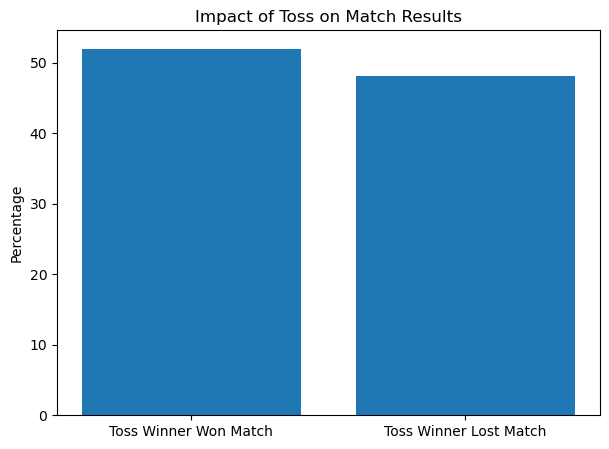

In [19]:
labels = [
    'Toss Winner Won Match',
    'Toss Winner Lost Match'
]

plt.figure(figsize=(7,5))

plt.bar(labels, toss_counts)

plt.ylabel("Percentage")
plt.title("Impact of Toss on Match Results")

# Insight
Team winning toss had the slightly higher match win percentage but suggesting that overall team
perfomance matters more then toss advantage 

## Phase Analysis

In [22]:
def get_phase(over):
    
    if over <= 6:
        return 'Powerplay'
    
    elif over <= 15:
        return 'Middle Overs'
    
    else:
        return 'Death Overs'

ipl_data['phase'] = ipl_data['over'].apply(get_phase)        

In [28]:
# ipl_data[['over', 'phase']].head(120)

Seperate winning and losing team

In [29]:
winning_teams = ipl_data[
    ipl_data['batting_team'] == ipl_data['winner']
]

losing_teams = ipl_data[
    ipl_data['batting_team'] != ipl_data['winner']
]

Average run per phase 

In [39]:
# Winning Team 
win_phase = (winning_teams.groupby('phase')['runs_total'].mean())

In [40]:
# Losing team 
lose_phase = (losing_teams.groupby("phase")["runs_total"].mean())

In [41]:
phase_df = pd.DataFrame({
    'Winning Teams': win_phase,
    'Losing Teams': lose_phase
})

print(phase_df)

              Winning Teams  Losing Teams
phase                                    
Death Overs        1.808065      1.471353
Middle Overs       1.399030      1.233753
Powerplay          1.343868      1.191802


## Create Visualization

(array([0, 1, 2]),
 [Text(0, 0, 'Death Overs'),
  Text(1, 0, 'Middle Overs'),
  Text(2, 0, 'Powerplay')])

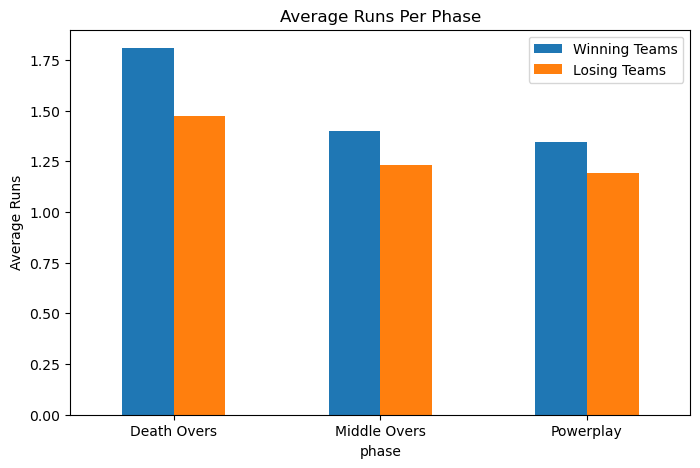

In [42]:
phase_df.plot(kind='bar',figsize=(8,5))

plt.title("Average Runs Per Phase")
plt.ylabel("Average Runs")
plt.xticks(rotation=0)

## insights
Death-over scoring showed the strongest relationship with match winning

## Top Batters

In [ ]:
Include:

table
chart
insight

## Top Bowlers

In [ ]:
Include:

table
chart
insight

## Final Insights

In [ ]:
Very important

Write:

what surprised you
overall findings